<a href="https://colab.research.google.com/github/yogeshne9i/Stock_Price_Analysis_Major/blob/main/04_LSTM_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
df = pd.read_csv("US_Stock_Data.csv")

df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date')

prices = df[['Netflix_Price']].values

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_prices = scaler.fit_transform(prices)


In [ ]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_prices)

X = X.reshape(X.shape[0], X.shape[1], 1)


In [ ]:
train_size = int(len(X)*0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=32)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1309
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0211
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0143
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0189
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0189
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0145
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0177
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0186
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0157
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0143


In [ ]:
predicted = model.predict(X_test)
predicted = scaler.inverse_transform(predicted.reshape(-1,1))

actual = scaler.inverse_transform(y_test.reshape(-1,1))


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


In [ ]:
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)


LSTM MAE: 36.728427785503925
LSTM RMSE: 45.34631286208073


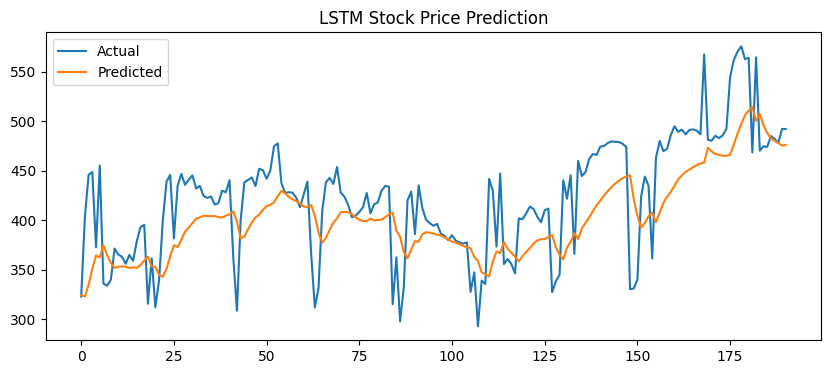

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(actual, label="Actual")
plt.plot(predicted, label="Predicted")
plt.legend()
plt.title("LSTM Stock Price Prediction")
plt.show()
